In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os

os.getcwd()

'/Users/selamwubeneh/Documents/Dataanalysiswithpyproject2'

In [4]:
os.listdir()

['Healthcareinsurancecost-1.ipynb']

In [5]:
df = pd.read_excel(
    "/Users/selamwubeneh/Desktop/Healthcare_Insurance_Analysis.xlsx",
    sheet_name="Cleaned_Dat"
)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.shape

(1108, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1108 entries, 0 to 1107
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1108 non-null   int64  
 1   sex       1108 non-null   object 
 2   bmi       1108 non-null   float64
 3   children  1108 non-null   int64  
 4   smoker    1108 non-null   object 
 5   region    1108 non-null   object 
 6   charges   1108 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 60.7+ KB


In [8]:
df.describe()

,age,bmi,children,charges
count,1108.000000,1108.000000,1108.000000,1108.000000
mean,39.211191,30.574084,1.055054,13292.706414
std,14.184313,6.126392,1.197574,12160.204434
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4719.193925
50%,39.000000,30.210000,1.000000,9447.316375
75%,51.250000,34.681250,2.000000,16604.302645
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.describe(include='object')

,sex,smoker,region
count,1108,1108,1108
unique,2,2,4
top,male,no,southeast
freq,564,880,296


In [ ]:
# We already know there are no missing values, but this is a good Python data-quality verification to document in the notebook.
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
#  Numerical summary
df.describe()

,age,bmi,children,charges
count,1108.000000,1108.000000,1108.000000,1108.000000
mean,39.211191,30.574084,1.055054,13292.706414
std,14.184313,6.126392,1.197574,12160.204434
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4719.193925
50%,39.000000,30.210000,1.000000,9447.316375
75%,51.250000,34.681250,2.000000,16604.302645
max,64.000000,53.130000,5.000000,63770.428010


In [12]:
# Categorical summary
df.describe(include='object')

,sex,smoker,region
count,1108,1108,1108
unique,2,2,4
top,male,no,southeast
freq,564,880,296


In [13]:
# Missing-value check
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

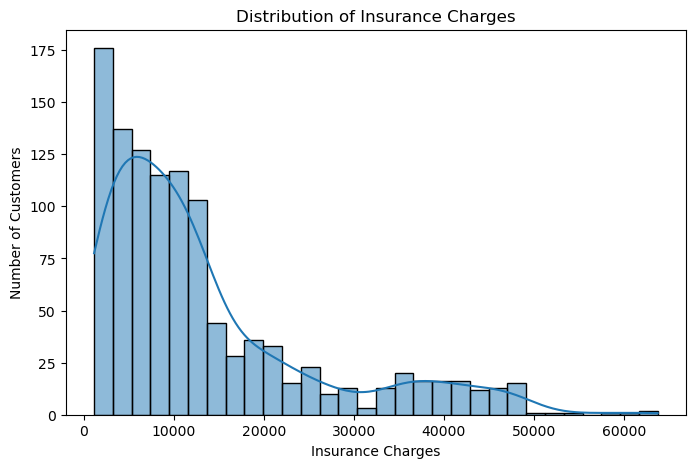

In [ ]:
# EDA  Distribution of Insurance Charges: First, let's see how insurance charges are distributed.
plt.figure(figsize=(8, 5))

sns.histplot(df['charges'], bins=30, kde=True)

plt.xlabel('Insurance Charges')
plt.ylabel('Number of Customers')
plt.title('Distribution of Insurance Charges')

plt.show()
# What we're looking for

# the distribution is right-skewed—most customers have relatively lower charges,
# while a smaller number of customers have much higher charges.

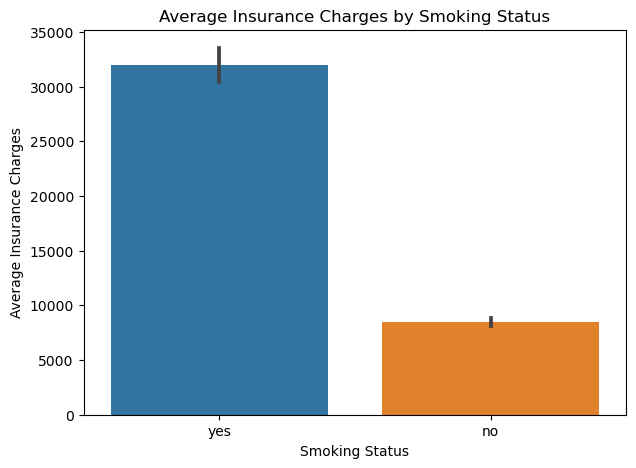

In [ ]:
# EDA 2 — Average Charges by Smoking Status
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x='smoker',
    y='charges',
    estimator='mean'
)

plt.xlabel('Smoking Status')
plt.ylabel('Average Insurance Charges')
plt.title('Average Insurance Charges by Smoking Status')

plt.show()

# below our chart shows Smoking status showed a strong association with insurance charges. 
# In the cleaned dataset, the average charge for smokers was substantially higher than for non-smokers.

In [16]:
df.groupby('smoker')['charges'].mean().round(2)

smoker
no      8444.95
yes    32003.36
Name: charges, dtype: float64

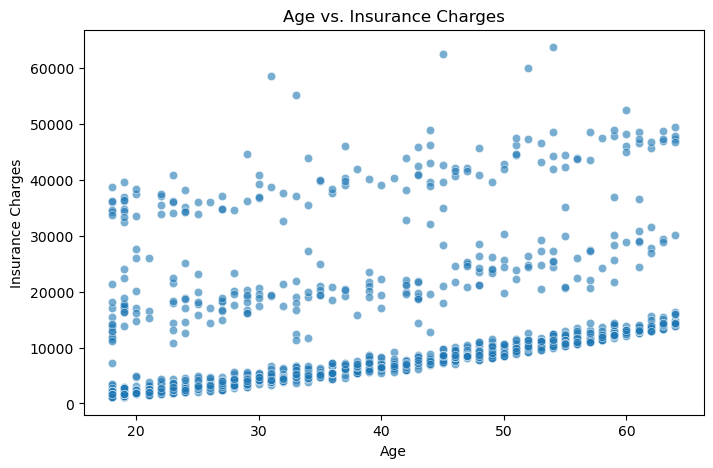

In [ ]:
# EDA 3 — Age vs. Insurance Charges
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='age',
    y='charges',
    alpha=0.6
)

plt.xlabel('Age')
plt.ylabel('Insurance Charges')
plt.title('Age vs. Insurance Charges')

plt.show()

# charges generally increase as age increases, but there is considerable variation.

#  also  notice that the highest charges are concentrated among certain customers rather than simply being explained by age alone.

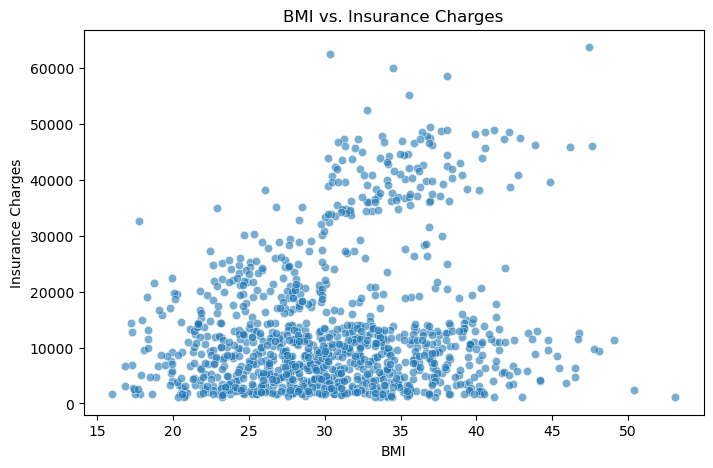

In [ ]:
# EDA 4 — BMI vs. Insurance Charges
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='bmi',
    y='charges',
    alpha=0.6
)

plt.xlabel('BMI')
plt.ylabel('Insurance Charges')
plt.title('BMI vs. Insurance Charges')

plt.show()

# Interpretation

# BMI should show a positive but fairly variable relationship with charges.
# BMI showed a positive but highly variable relationship with insurance charges. 
# While higher charges appeared more frequently at higher BMI levels, BMI alone did not explain the variation in costs.

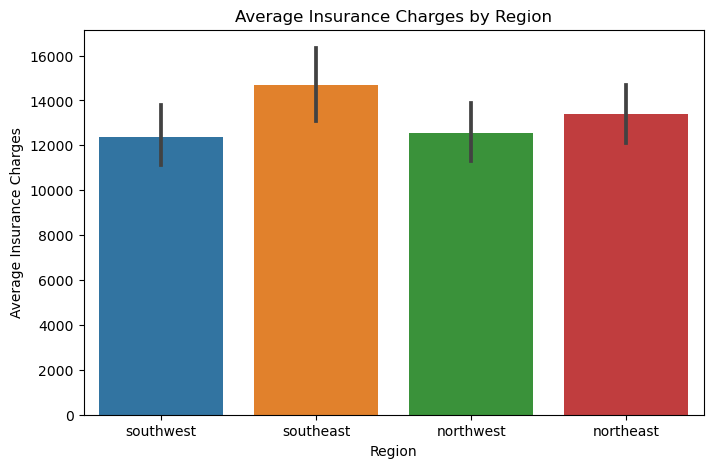

In [ ]:
# EDA 5 — Charges by Region
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='region',
    y='charges',
    estimator='mean'
)

plt.xlabel('Region')
plt.ylabel('Average Insurance Charges')
plt.title('Average Insurance Charges by Region')

plt.show()

# ### Interpretation

# Insurance charges varied across regions, with the Southeast showing the highest average insurance charges and the Southwest showing the lowest average charges in the cleaned dataset. 
# However, the differences between regions were relatively moderate compared with the much larger difference observed by smoking status.

# This suggests that region may be associated with differences in insurance charges, but it does not appear to explain as much variation in costs as some of the other variables in the dataset.

In [ ]:
# machine learning preparation
# Create a copy for machine learning
# Why are we doing this?

# The regression models can't work directly with text such as:female:male,yes,, no, northeast, southwest
# df remains your clean dataset. df_model is just the machine-learning version.
df_model = df.copy()

# Convert sex to numeric
df_model['sex'] = df_model['sex'].map({
    'female': 0,
    'male': 1
})

# Convert smoker to numeric
df_model['smoker'] = df_model['smoker'].map({
    'no': 0,
    'yes': 1
})

# Convert region into separate numeric columns
df_model = pd.get_dummies(
    df_model,
    columns=['region'],
    prefix='region',
    dtype=int
)

df_model.head()


,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


In [21]:
# Step 2 — Separate X and y
# X = input/predictor variables
# y = target variable we want to predict

X = df_model.drop(columns='charges')
y = df_model['charges']

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['age', 'sex', 'bmi', 'children', 'smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']

Target:
charges


In [ ]:
# Step 3 — Split into training and testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))


Training records: 886
Testing records: 222


In [ ]:
# Step 4 — Build our baseline model

#  starting with Linear Regression.
from sklearn.linear_model import LinearRegression

# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions on the test data
linear_predictions = linear_model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

linear_r2 = r2_score(y_test, linear_predictions)
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))

print("Linear Regression Performance")
print("-----------------------------")
print("R²:", round(linear_r2, 3))
print("MAE:", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))

# What we're measuring

# R² → How much of the variation in insurance charges the model explains.

# MAE → On average, how many dollars our predictions are away from the actual charges.

# RMSE → Similar to MAE, but it penalizes larger prediction errors more heavily.

Linear Regression Performance
-----------------------------
R²: 0.768
MAE: 3966.06
RMSE: 5569.57


In [25]:
# Next: Decision Tree

# Now we'll see whether a decision tree can improve on our baseline.

from sklearn.tree import DecisionTreeRegressor

# Create and train the Decision Tree model
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

# Make predictions
dt_predictions = dt_model.predict(X_test)

In [ ]:
dt_r2 = r2_score(y_test, dt_predictions)
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))

print("Decision Tree Performance")
print("-------------------------")
print("R²:", round(dt_r2, 3))
print("MAE:", round(dt_mae, 2))
print("RMSE:", round(dt_rmse, 2))

# The Decision Tree reduced the MAE compared with the Linear Regression baseline, but its R² was lower and its RMSE was higher. 
# This showed me that a lower average error doesn't necessarily mean the model performs better across all aspects, 
# so I compared multiple evaluation metrics before selecting a model

Decision Tree Performance
-------------------------
R²: 0.71
MAE: 3002.06
RMSE: 6223.14


In [28]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

# Create and train the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

In [29]:
rf_r2 = r2_score(y_test, rf_predictions)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("Random Forest Performance")
print("-------------------------")
print("R²:", round(rf_r2, 3))
print("MAE:", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))

Random Forest Performance
-------------------------
R²: 0.821
MAE: 2945.06
RMSE: 4890.19


In [ ]:
## Model Comparison

# Three regression models were evaluated using the same training and test datasets:

# - Linear Regression
# - Decision Tree
# - Random Forest

# Random Forest achieved the highest R² and the lowest MAE and RMSE among the three models evaluated on the test dataset.

# The Random Forest model achieved an R² of 0.821, meaning it explained approximately 82.1% of the variation in insurance charges in the test dataset. Its average absolute prediction error (MAE) was approximately $2,945, while its RMSE was approximately $4,890.

# The results suggest that the Random Forest model captured nonlinear patterns in the insurance dataset that were not fully captured by the simpler models.

In [30]:
model_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'R²': [
        linear_r2,
        dt_r2,
        rf_r2
    ],
    'MAE': [
        linear_mae,
        dt_mae,
        rf_mae
    ],
    'RMSE': [
        linear_rmse,
        dt_rmse,
        rf_rmse
    ]
})

model_results.round(2)

,Model,R²,MAE,RMSE
0,Linear Regression,0.77,3966.06,5569.57
1,Decision Tree,0.71,3002.06,6223.14
2,Random Forest,0.82,2945.06,4890.19


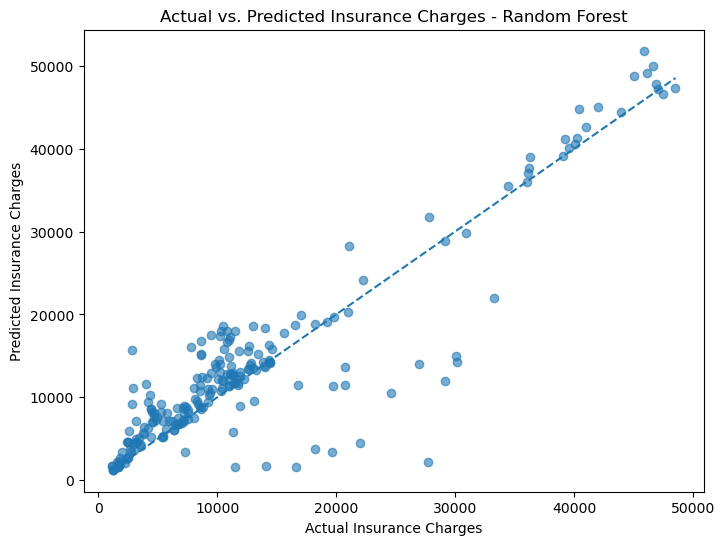

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Insurance Charges')
plt.ylabel('Predicted Insurance Charges')
plt.title('Actual vs. Predicted Insurance Charges - Random Forest')

plt.show()

In [ ]:
# 1. Interpret the Actual vs. Predicted chart
## Actual vs. Predicted Insurance Charges

# The Actual vs. Predicted plot shows that the Random Forest model generally follows the overall pattern of the actual insurance charges. 
# Predictions are relatively close to the actual values for many observations, while larger differences appear among some of the higher-cost customers.

# The model performs reasonably well overall, but it does not perfectly predict every individual insurance charge.
# This is expected because insurance costs can vary substantially between customers with similar demographic characteristics.



In [ ]:
# Python Analysis — Key Findings

## Exploratory Analysis

# The distribution of insurance charges was right-skewed, with most customers having lower charges and  a smaller number of customers having substantially higher charges.
#  Smoking status showed a strong association with insurance charges. Smokers had substantially higher average charges than non-smokers.
# Insurance charges generally increased with age, although there was considerable variation between customers.
# BMI showed a positive but highly variable relationship with insurance charges.
# Regional differences in average charges were present, but they were less pronounced than the difference observed by smoking status.

# ## Predictive Modeling

# Three regression models were evaluated:

# Linear Regression
# Decision Tree
# Random Forest

# Linear Regression was used as the baseline model and achieved an R² of approximately 0.768.

# The Decision Tree produced a lower R² of approximately 0.710, although its MAE was lower than the Linear Regression model.

# Random Forest produced the strongest results among the three models evaluated on the test dataset, with:

#  R²: 0.821
# MAE: approximately $2,945
#  RMSE: approximately $4,890

# The results suggest that the Random Forest model captured nonlinear patterns in the dataset that were not fully captured by the simpler models.

# ## Conclusion

# The analysis indicates that insurance charges are associated with multiple customer characteristics rather than a single factor. 
# Smoking status showed one of the strongest visible differences in average charges, while age and BMI demonstrated more variable relationships.

# The modeling results suggest that an ensemble model such as Random Forest can capture more complex patterns in insurance charges than a simple linear regression model.

# These findings are descriptive and predictive rather than causal. The dataset can be used to identify patterns and estimate charges, 
# but the analysis does not establish that any individual characteristic directly causes higher insurance costs.